In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 7  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

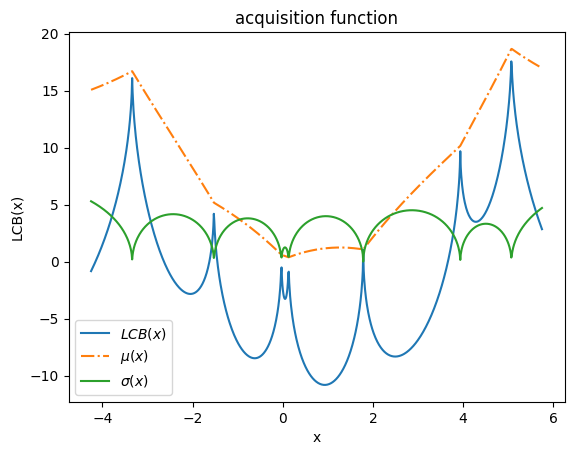

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [4]:
# ---- Use only BnBAlgorithmBase methods + SMT predict_* for reference ----

sm = gp_model.surrogatesmt

# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = "IPOPT"          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 100
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)

for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        #print(f"LCB node bounds:  L={LCB_L:.9f}   U={LCB_U:.9f}")
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

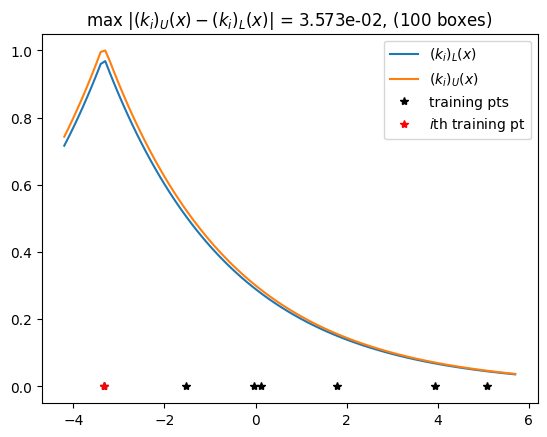

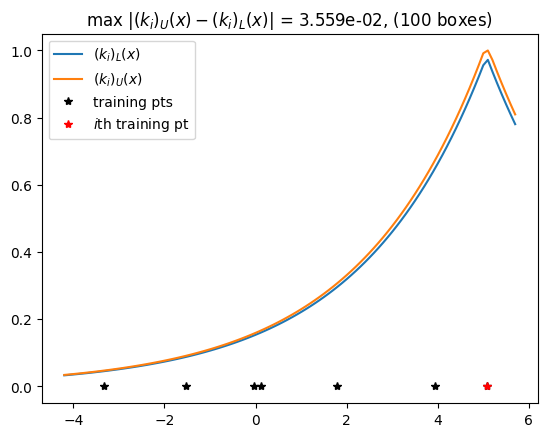

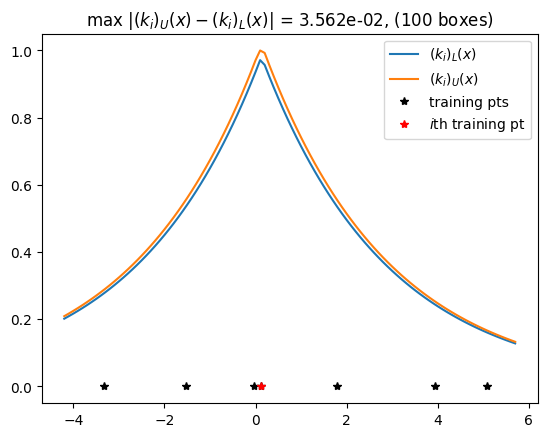

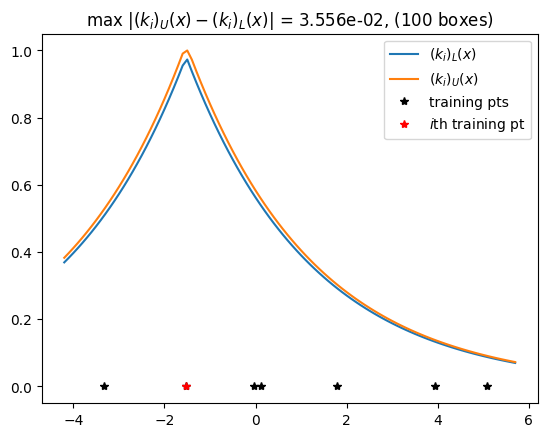

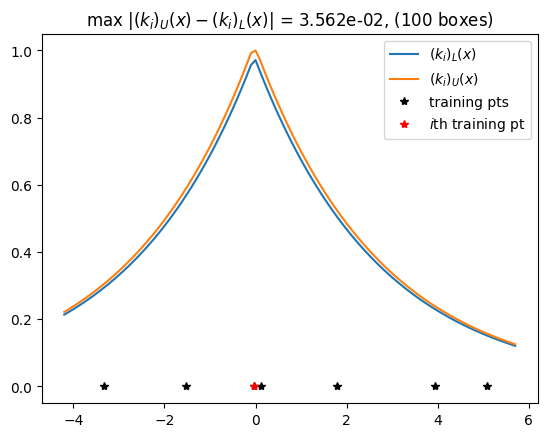

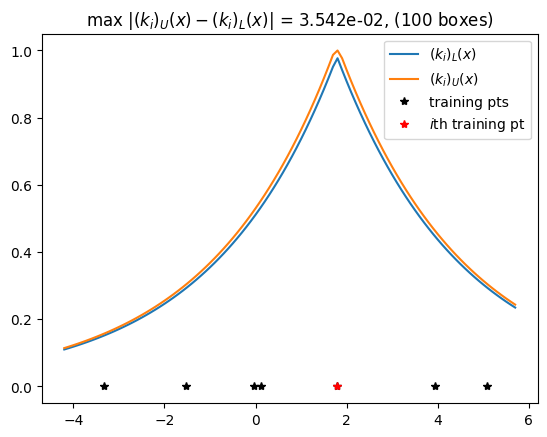

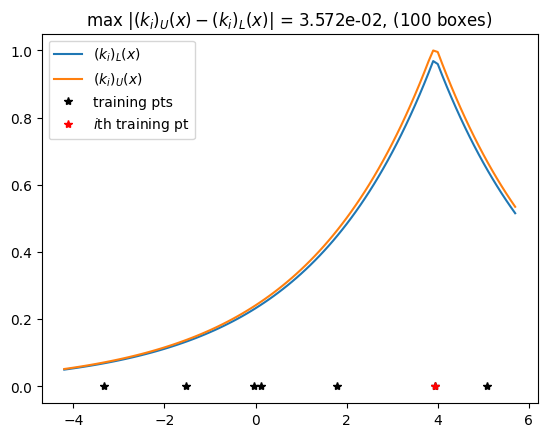

In [5]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

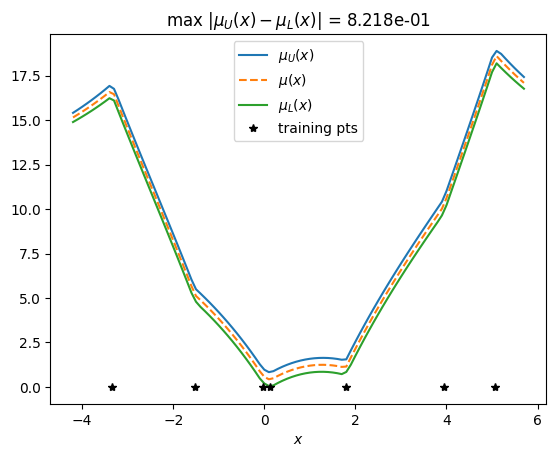

In [6]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

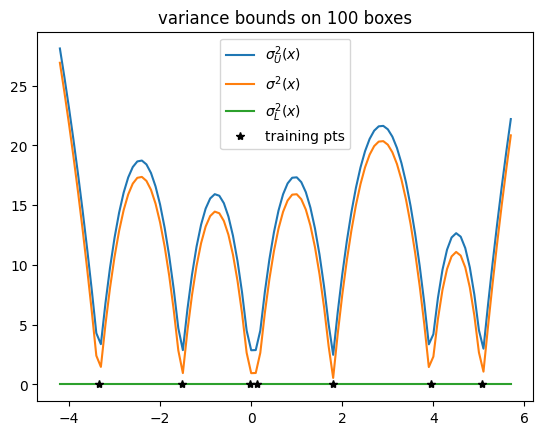

In [7]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(midpoints, s2, label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()